Mencari file data Pristine Bragg Peak (PBP_*.csv)...
Berhasil mendeteksi 23 file simulasi energi.

Menjalankan mesin optimasi L-BFGS-B...

 HASIL OPTIMASI BOBOT PARTIKEL (23 LAYER ENERGI)
Layer  1 | File:  PBP_147.08.csv | Bobot:   95227 partikel
Layer  2 | File:  PBP_146.53.csv | Bobot:  100000 partikel
Layer  3 | File:  PBP_145.97.csv | Bobot:   92502 partikel
Layer  4 | File:  PBP_145.42.csv | Bobot:   62145 partikel
Layer  5 | File:  PBP_144.86.csv | Bobot:   28892 partikel
Layer  6 | File:  PBP_144.31.csv | Bobot:   12824 partikel
Layer  7 | File:  PBP_143.75.csv | Bobot:   22478 partikel
Layer  8 | File:  PBP_143.19.csv | Bobot:   32025 partikel
Layer  9 | File:  PBP_142.62.csv | Bobot:   27167 partikel
Layer 10 | File:  PBP_142.06.csv | Bobot:   18985 partikel
Layer 11 | File:  PBP_141.49.csv | Bobot:   17457 partikel
Layer 12 | File:  PBP_140.92.csv | Bobot:   19610 partikel
Layer 13 | File:  PBP_140.35.csv | Bobot:   19237 partikel
Layer 14 | File:  PBP_139.78.csv | Bobot:   1

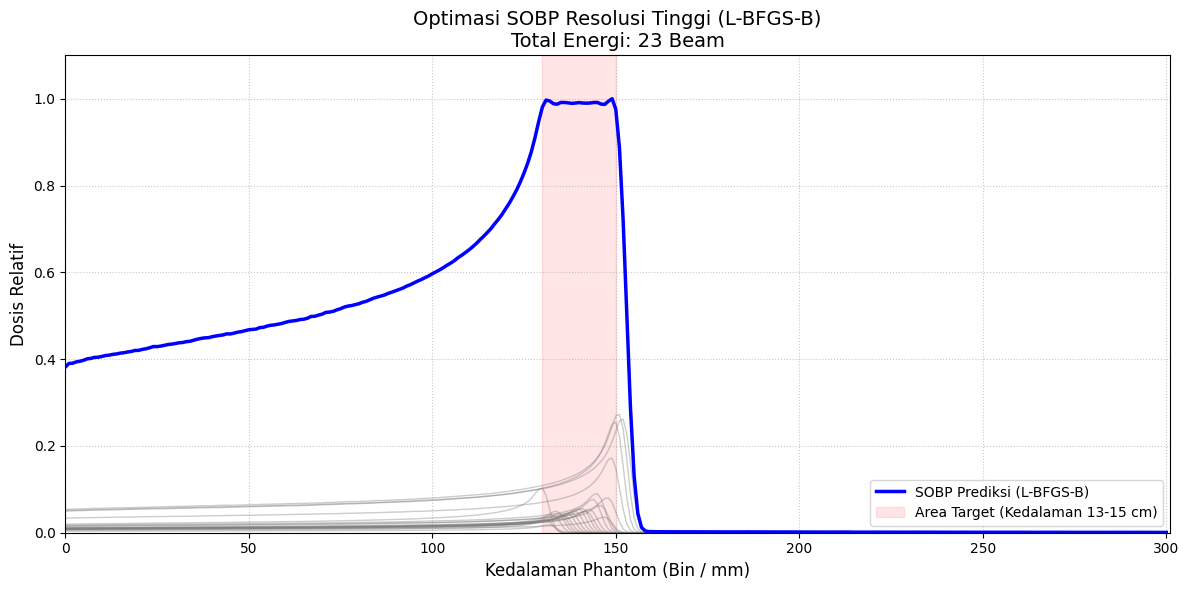

In [6]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re

# ==========================================
# 1. PENGATURAN TARGET & AUTO-LOAD FILE
# ==========================================
target_start = 130  # Sisi proksimal tumor (Bin 130)
target_end = 150    # Sisi distal tumor (Bin 150)
maksimal_partikel = 100000 # Skala maksimal partikel untuk TOPAS

print("Mencari file data Pristine Bragg Peak (PBP_*.csv)...")
# Mengambil semua file yang berawalan "PBP_" dan berakhiran ".csv" di folder yang sama
file_list_mentah = glob.glob("PBP_*.csv")

# Fungsi pintar untuk membaca angka energi di dalam nama file dan mengurutkannya
def ambil_energi(nama_file):
    angka = re.findall(r"\d+\.\d+|\d+", nama_file)
    return float(angka[0]) if angka else 0.0

# Mengurutkan file dari energi paling besar (terdalam) ke paling kecil
file_list = sorted(file_list_mentah, key=ambil_energi, reverse=True)

if not file_list:
    print("ERROR: Tidak ada file PBP_*.csv yang ditemukan di folder ini!")
else:
    print(f"Berhasil mendeteksi {len(file_list)} file simulasi energi.")

# ==========================================
# 2. EKSTRAKSI DATA & PENYUSUNAN MATRIKS
# ==========================================
dose_matrix = []
for file in file_list:
    # Membaca CSV, mengabaikan header TOPAS, mengambil kolom paling kanan
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

# Menyeragamkan jumlah bin (memotong jika ada file yang bin-nya lebih panjang)
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# NORMALISASI MATRIKS (Kunci Utama Mencegah L-BFGS-B Mogok)
D_max = np.max(D)
D_norm = D / D_max

# Membuat Garis Target SOBP (Dosis disetel 1.0 di area tumor)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. FUNGSI LOSS KUSTOM (L-BFGS-B)
# ==========================================
def loss_function(w, D_mat, target):
    prediksi = D_mat.dot(w)
    
    # Fokus hitung error HANYA pada indeks 130 sampai 150
    error_tumor = np.mean((prediksi[target_start:target_end+1] - target[target_start:target_end+1])**2)
    
    # Penalti regularisasi mikroskopis agar kurva mulus tanpa riak
    smoothness_penalty = 0.001* np.sum(w**2) #################################################################################
    
    return error_tumor + smoothness_penalty

# ==========================================
# 4. EKSEKUSI OPTIMASI TPS (L-BFGS-B)
# ==========================================
print("\nMenjalankan mesin optimasi L-BFGS-B...")
# Tebakan awal (Initial Guess) disetel 0.1 partikel relatif
w0 = np.ones(D_norm.shape[1]) * 0.1 

# Bobot tidak boleh bernilai minus
batas = [(0, None) for _ in range(D_norm.shape[1])]
hasil = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=batas)

w_terbaik = hasil.x

# ==========================================
# 5. KONVERSI KE JUMLAH PARTIKEL TOPAS
# ==========================================
max_w = np.max(w_terbaik)
if max_w > 0:
    bobot_partikel = np.round((w_terbaik / max_w) * maksimal_partikel).astype(int)
else:
    bobot_partikel = np.zeros(len(w_terbaik), dtype=int)

print(f"\n{'='*65}")
print(f" HASIL OPTIMASI BOBOT PARTIKEL ({len(file_list)} LAYER ENERGI)")
print(f"{'='*65}")
for i, bobot in enumerate(bobot_partikel):
    print(f"Layer {i+1:2d} | File: {file_list[i]:>15} | Bobot: {bobot:7d} partikel")
print(f"{'='*65}\n")

# ==========================================
# 6. VISUALISASI SOBP AKHIR
# ==========================================
SOBP_prediksi_norm = D_norm.dot(w_terbaik)
max_dose_pred = np.max(SOBP_prediksi_norm)

# Skala akhir plot disesuaikan agar puncak dosis tepat di angka 1.0 (Relatif)
SOBP_plot = SOBP_prediksi_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
kedalaman_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot kurva 21 Pristine Beam individu
for i in range(len(w_terbaik)):
    if w_terbaik[i] > 0:
        plt.plot(kedalaman_mm, D_plot[:, i] * w_terbaik[i], color='gray', alpha=0.4, linewidth=1.0)

# Plot Kurva SOBP Gabungan
plt.plot(kedalaman_mm, SOBP_plot, 'b-', linewidth=2.5, label='SOBP Prediksi (L-BFGS-B)')

# Highlight Area Tumor Target
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Area Target (Kedalaman 13-15 cm)')

plt.title(f'Optimasi SOBP Resolusi Tinggi (L-BFGS-B)\nTotal Energi: {len(file_list)} Beam', fontsize=14)
plt.xlabel('Kedalaman Phantom (Bin / mm)', fontsize=12)
plt.ylabel('Dosis Relatif', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()